#### EDA - Análise Exploratória de Dados (EDA) 

1. Setup e carga do arquivo

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo de visualização padrão
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Carrega o dataset bruto (.csv) contendo dados de telemetria dos dispositivos
df = pd.read_csv("../data/Moto_HW_DATA_hashed.csv")

# Seleciona apenas as colunas mais relevantes para o nosso problema
cols = [
    "full_cap_min", "btlow_total", "dchrg_diff", "total_chrg_cnt",
    "son_hrs", "msgs_tot", "wifi_hrs", "mobile_rx_MB"
]
df = df[cols]

2. Criação de rótulo de ineficiência

label_ineficiente
1    0.52794
0    0.47206
Name: proportion, dtype: float64


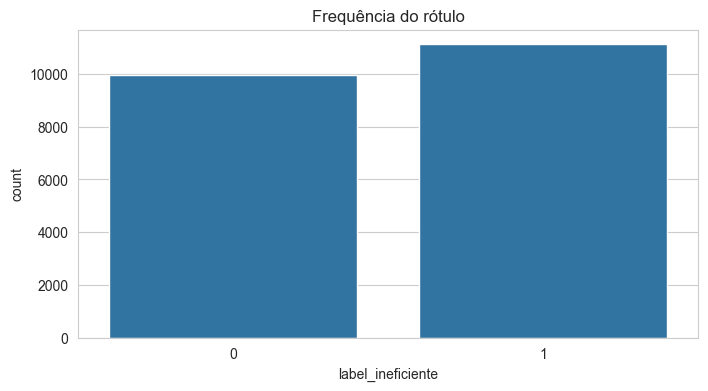

In [2]:
# Função para rotular um aparelho como "ineficiente" se:
# 1) Ele tiver uma variação de descarga alta (dchrg_diff > 25)
# 2) E também apresentar bateria desgastada (full_cap_min < 2800) ou alertas frequentes de bateria baixa (btlow_total > 10)

def make_label(row):
    return int(
        (row["dchrg_diff"] > 25)
        and ((row["full_cap_min"] < 2800) or (row["btlow_total"] > 10))
    )

df["label_ineficiente"] = df.apply(make_label, axis=1)

# Distribuição do alvo
print(df["label_ineficiente"].value_counts(normalize=True))
sns.countplot(x="label_ineficiente", data=df)
plt.title("Frequência do rótulo")
plt.show()

3. Visão geral

In [3]:
# display(df.head())
df.info()
df.describe().T   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21063 entries, 0 to 21062
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   full_cap_min       21063 non-null  float64
 1   btlow_total        21063 non-null  float64
 2   dchrg_diff         21063 non-null  float64
 3   total_chrg_cnt     21063 non-null  float64
 4   son_hrs            21063 non-null  float64
 5   msgs_tot           11386 non-null  float64
 6   wifi_hrs           21063 non-null  float64
 7   mobile_rx_MB       21063 non-null  float64
 8   label_ineficiente  21063 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.4 MB


,count,mean,std,min,25%,50%,75%,max
full_cap_min,21063.0,333131.836940,1.105046e+06,-1.0,-1.00,-1.00,4869.875,5081000.00
btlow_total,21063.0,23.399789,7.808618e+02,0.0,1.00,1.25,2.250,107014.00
dchrg_diff,21063.0,71.769253,3.799376e+01,0.0,45.25,67.00,92.000,721.00
total_chrg_cnt,21063.0,7.128694,1.301778e+01,0.0,2.00,3.50,7.000,347.50
son_hrs,21063.0,5.205605,2.769159e+00,0.0,3.00,5.00,7.000,21.00
msgs_tot,11386.0,96.929668,1.249211e+02,1.0,29.25,64.50,121.000,4533.00
wifi_hrs,21063.0,12.355275,1.837340e+01,0.0,2.00,7.00,21.000,752.00
mobile_rx_MB,21063.0,108.330611,2.660867e+02,0.0,0.00,0.00,104.250,7014.25
label_ineficiente,21063.0,0.527940,4.992306e-01,0.0,0.00,1.00,1.000,1.00


In [4]:
na = df.isna().sum().sort_values(ascending=False)
display(na[na > 0])   

msgs_tot    9677
dtype: int64

,mean,std,skew,kurtosis
feature,,,,
btlow_total,23.399789,7.808618e+02,123.903613,16773.506771
wifi_hrs,12.355275,1.837340e+01,13.936419,377.447396
msgs_tot,96.929668,1.249211e+02,10.452005,272.042781
total_chrg_cnt,7.128694,1.301778e+01,8.074835,109.228733
mobile_rx_MB,108.330611,2.660867e+02,6.166605,70.123534
full_cap_min,333131.836940,1.105046e+06,3.200614,8.794286
dchrg_diff,71.769253,3.799376e+01,1.383958,7.623548
son_hrs,5.205605,2.769159e+00,0.510442,0.450503


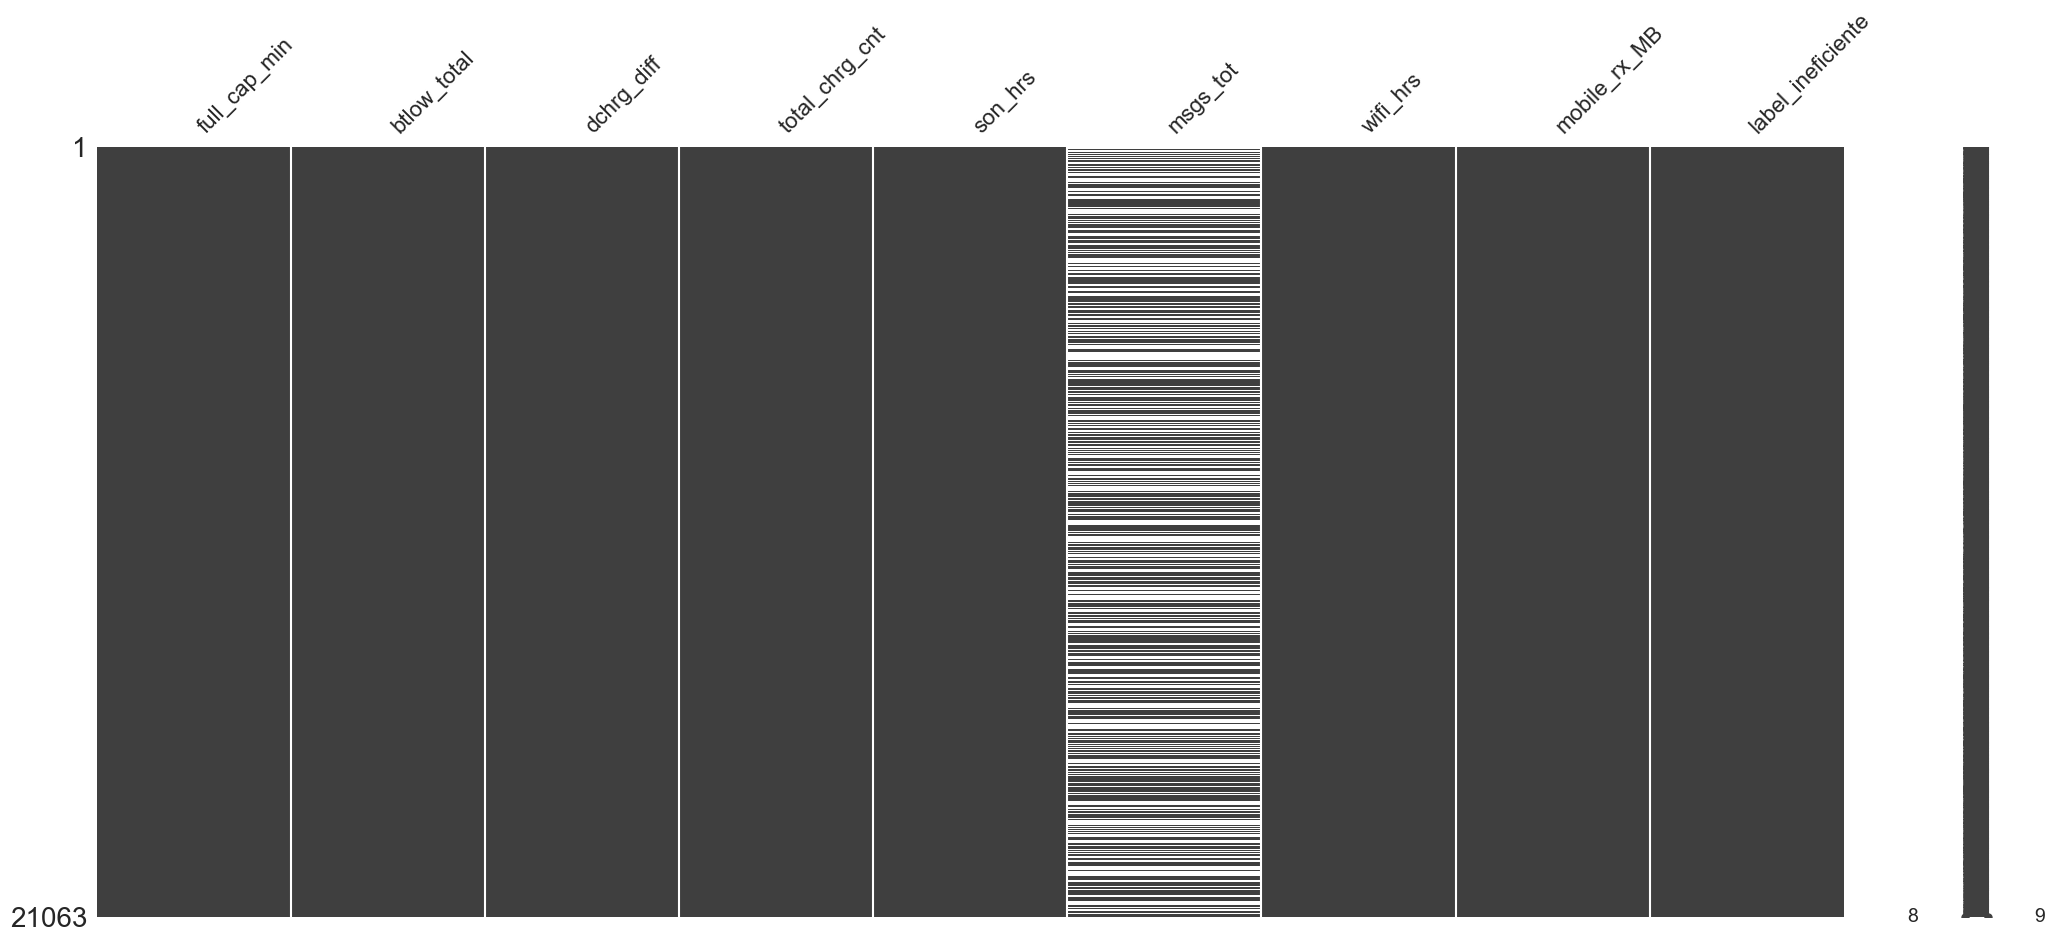

<Figure size 600x500 with 0 Axes>

In [8]:
import missingno as msno
from scipy.stats import skew, kurtosis

# --- missing values visual ---
msno.matrix(df)
plt.savefig("../outputs/figures/eda_missing_matrix.png")

# --- skew & kurtosis table ---
stats = []

for col in cols:
    stats.append({
        "feature": col,
        "mean": df[col].mean(),
        "std": df[col].std(),
        "skew": skew(df[col].dropna()),
        "kurtosis": kurtosis(df[col].dropna())
    })

sk_table = pd.DataFrame(stats).set_index("feature").sort_values("skew", ascending=False)

display(sk_table)

# --- correlation heatmap ---
plt.figure(figsize=(6,5))
sns.heatmap(df[cols].corr(method="spearman"), cmap="vlag", center=0, annot=False)
plt.title("Correlação Spearman")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_corr.png")

# --- label vs. feature distributions ---
for c in cols:
    sns.kdeplot(data=df, x=c, hue="label_ineficiente", common_norm=False)
    plt.title(f"{c} vs label")
    plt.savefig(f"../outputs/figures/eda_{c}_kde.png")
    plt.clf()